# ETTS Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the ETTS dataset.

**Objectives:**
- Compare S4 vs LMU performance across different ETT datasets
- Analyze data efficiency (which model learns better with less data)
- Visualize learning curves
- Identify the best model/fraction combination for each dataset

**Datasets:** ETTh1, ETTh2, ETTm1, ETTm2
**Fractions tested:** 10%, 25%, 50%, 75%


In [6]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent.parent))

import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Imports successful")

Imports successful


## 2. Select Dataset to Compare

Choose which ETT dataset to analyze. Available options:
- `etth1` - ETT Hourly dataset 1
- `etth2` - ETT Hourly dataset 2
- `ettm1` - ETT 15-minute dataset 1
- `ettm2` - ETT 15-minute dataset 2


In [7]:
# ============================================
# CONFIGURATION - Change dataset here
# ============================================
dataset = "etth1"  # Options: 'etth1', 'etth2', 'ettm1', 'ettm2'

# Standard configuration
base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 0.75, 1.0]

print(f"Selected dataset: {dataset.upper()}")
print(f"Models: {', '.join([m.upper() for m in models])}")
print(f"Fractions: {', '.join([f'{int(f*100)}%' for f in fractions])}")


Selected dataset: ETTH1
Models: S4, LMU
Fractions: 10%, 25%, 50%, 75%, 100%


## 3. Load ETTS Experiment Results

Load all S4 and LMU results for the selected dataset across different data fractions.


In [19]:
print("="*60)
print(f"LOADING {dataset.upper()} EXPERIMENT RESULTS")
print("="*60)
print()

def load_etts_experiments(base_dir, models, fractions, dataset):
    """Load ETTS experiments with custom naming convention."""
    base_path = Path(base_dir)
    all_results = {}

    for model in models:
        all_results[model] = {}

        for frac in fractions:
            frac_pct = int(frac * 100)
            run_name = f"etts_{model}_task_{dataset}"

            if frac_pct < 100:
                run_name += f"_frac{frac_pct}"

            run_dir = base_path / run_name

            if run_dir.exists():
                checkpoint_path = run_dir / "best.pt"
                if checkpoint_path.exists():
                    print(f"Loading {model.upper()} @ {frac*100:.0f}%: {run_name}")
                    try:
                        checkpoint = torch.load(checkpoint_path, map_location='cpu')
                        history = checkpoint.get('history', {})

                        results = {
                            'run_dir': str(run_dir),
                            'history': history,
                            'checkpoint_path': str(checkpoint_path),
                        }

                        # Extract metrics
                        if 'val_loss' in history and history['val_loss']:
                            results['best_val_loss'] = min(history['val_loss'])
                            results['final_val_loss'] = history['val_loss'][-1]
                            results['epochs_trained'] = len(history['val_loss'])

                        if 'val_mae' in history and history['val_mae']:
                            results['best_val_mae'] = min(history['val_mae'])
                            results['final_val_mae'] = history['val_mae'][-1]

                        if 'train_loss' in history and history['train_loss']:
                            results['final_train_loss'] = history['train_loss'][-1]

                        all_results[model][frac] = results
                    except Exception as e:
                        print(f"Error loading: {e}")
                        all_results[model][frac] = {}
                else:
                    print(f"Checkpoint not found: {run_name}")
                    all_results[model][frac] = {}
            else:
                print(f"Run not found: {run_name}")
                all_results[model][frac] = {}

    return all_results

# Load results
all_results = load_etts_experiments(base_dir, models, fractions, dataset)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

# Quick summary
for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")


LOADING ETTH1 EXPERIMENT RESULTS

Loading S4 @ 10%: etts_s4_task_etth1_frac10
Loading S4 @ 25%: etts_s4_task_etth1_frac25
Loading S4 @ 50%: etts_s4_task_etth1_frac50
Loading S4 @ 75%: etts_s4_task_etth1_frac75
Loading S4 @ 100%: etts_s4_task_etth1
Loading LMU @ 10%: etts_lmu_task_etth1_frac10
Loading LMU @ 25%: etts_lmu_task_etth1_frac25
Loading LMU @ 50%: etts_lmu_task_etth1_frac50
Loading LMU @ 75%: etts_lmu_task_etth1_frac75
Loading LMU @ 100%: etts_lmu_task_etth1

LOADING COMPLETE
S4: Loaded 5/5 experiments
LMU: Loaded 5/5 experiments


## 4. Comparison Table

Summary table of all experiments and their metrics.


In [9]:
from src.eval.compare import create_comparison_table

print("="*60)
print(f"EXPERIMENT COMPARISON TABLE - {dataset.upper()}")
print("="*60)
print()

comparison_df = create_comparison_table(
    all_results,
    metrics=['best_val_mae', 'best_val_loss', 'final_val_mae', 'epochs_trained']
)

print(comparison_df.to_string(index=False))
print()

# Save to CSV
csv_path = Path(f"./comparison_results_{dataset}.csv")
comparison_df.to_csv(csv_path, index=False)
print(f"Saved to: {csv_path}")


EXPERIMENT COMPARISON TABLE - ETTH1

Model Data %  Fraction best_val_mae best_val_loss final_val_mae  epochs_trained
   S4    10%      0.10       0.3560        0.1807        0.3560              38
   S4    25%      0.25       0.3517        0.1859        0.3517              18
   S4    50%      0.50       0.3753        0.2070        0.3753               6
   S4    75%      0.75       0.1944        0.0641        0.1944              36
   S4   100%      1.00       0.2132        0.0728        0.2132              32
  LMU    10%      0.10       0.2870        0.1288        0.2870              19
  LMU    25%      0.25       0.3429        0.1732        0.3429               6
  LMU    50%      0.50       0.3069        0.1604        0.3069              11
  LMU    75%      0.75       0.2915        0.1557        0.2915              10
  LMU   100%      1.00       0.2769        0.1299        0.2769              19

Saved to: comparison_results_etth1.csv


## 5. Validation Loss Learning Curves

Compare how validation loss evolves during training for different data fractions.


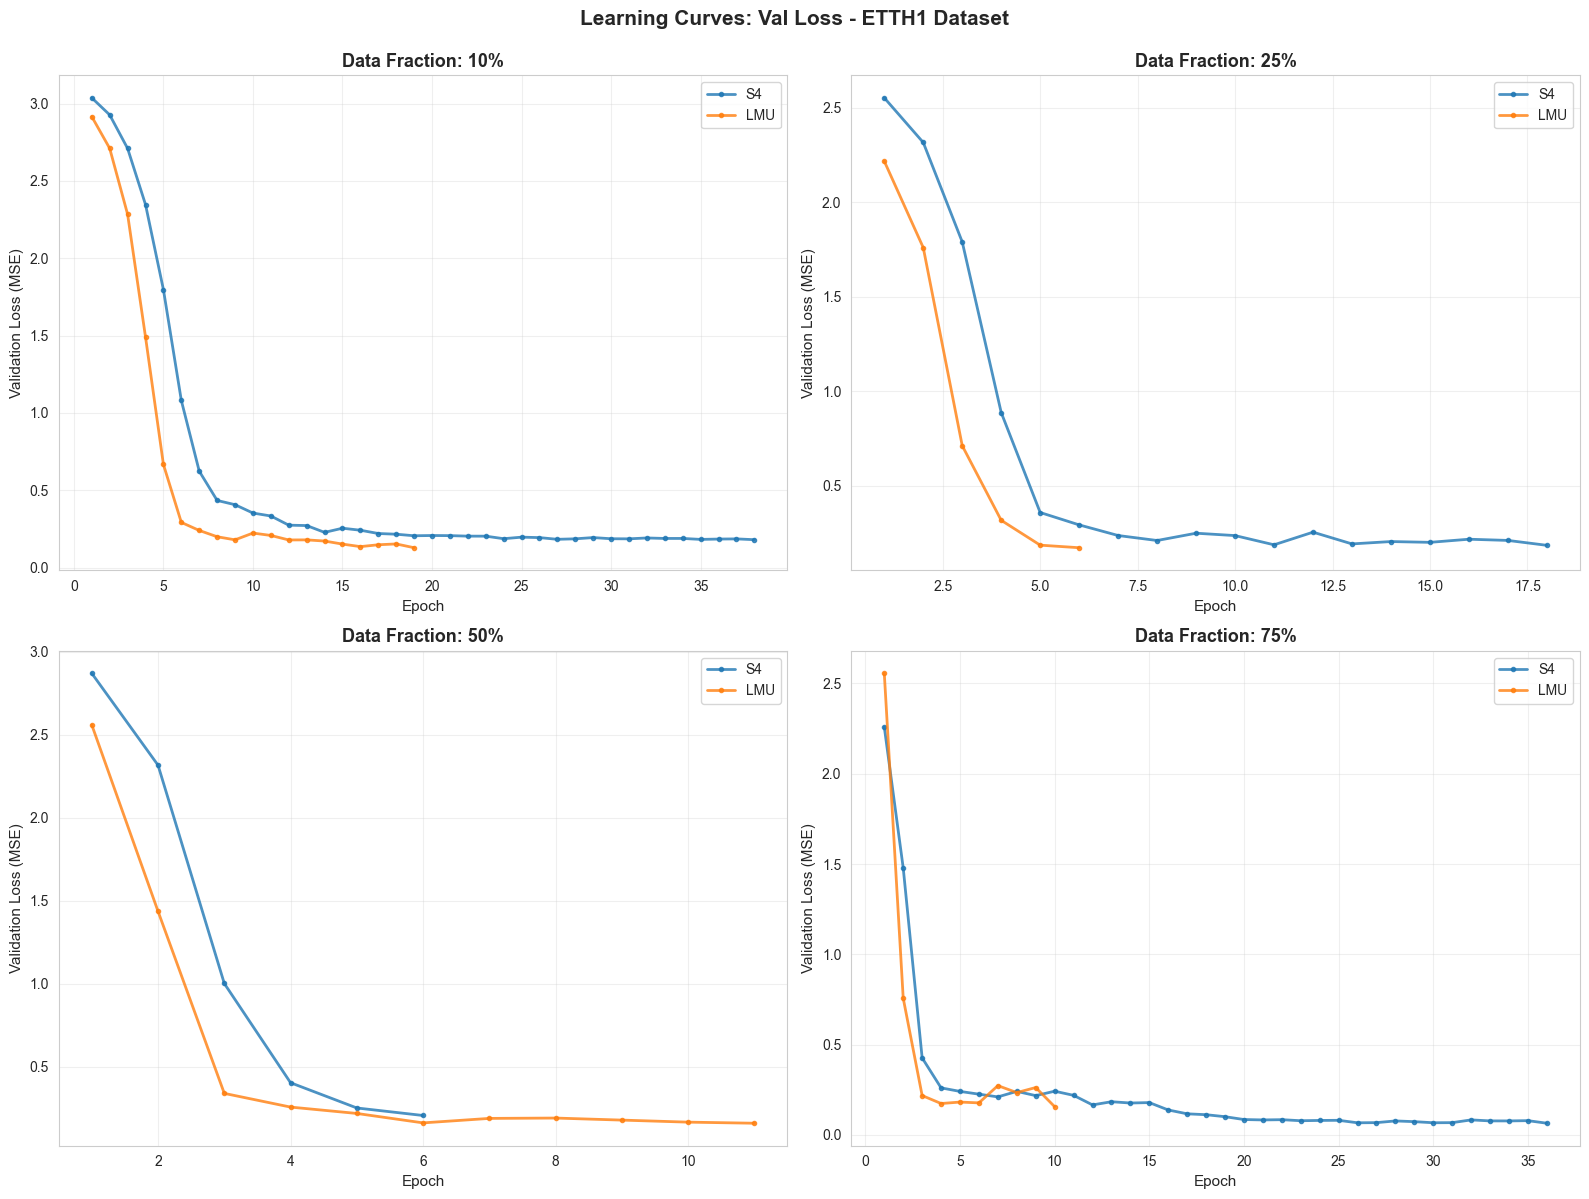

In [10]:
from src.eval.compare import plot_learning_curves

plot_learning_curves(
    all_results,
    metric='val_loss',
    title_suffix=f' - {dataset.upper()} Dataset',
    ylabel='Validation Loss (MSE)'
)


## 6. Validation MAE Learning Curves

Compare MAE (Mean Absolute Error) across training.


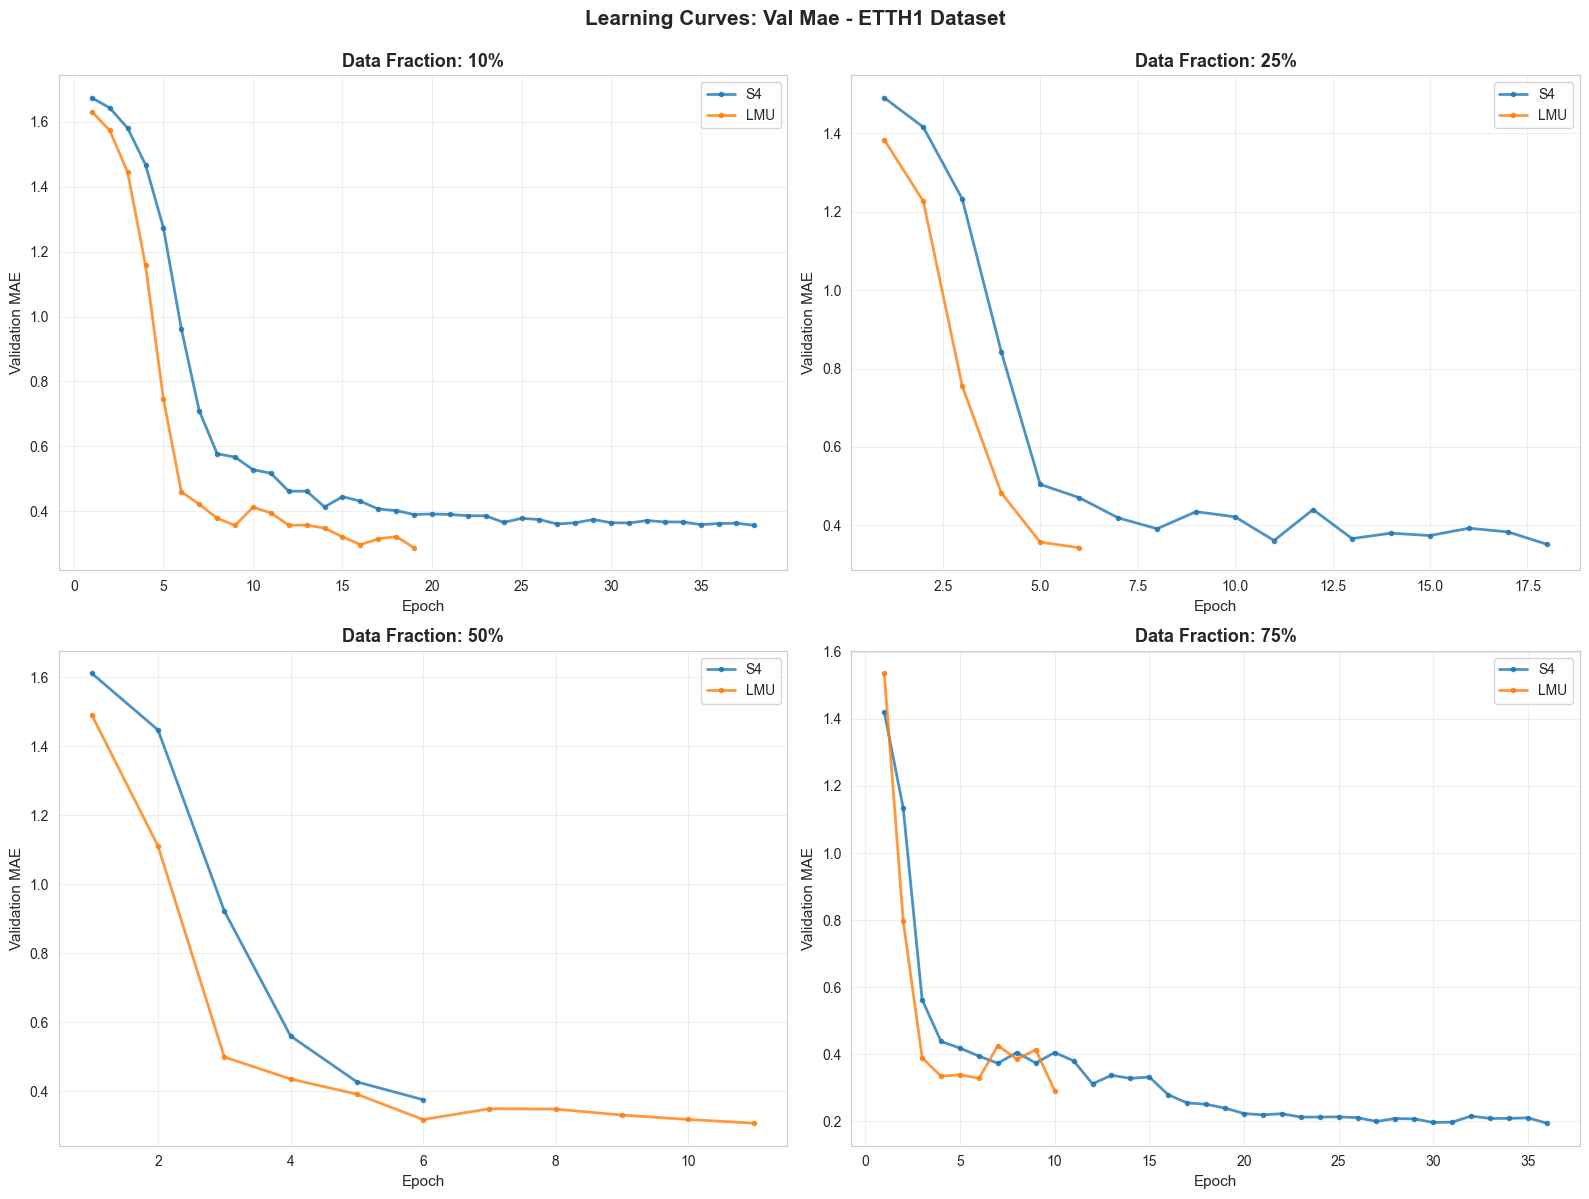

In [11]:
plot_learning_curves(
    all_results,
    metric='val_mae',
    title_suffix=f' - {dataset.upper()} Dataset',
    ylabel='Validation MAE'
)


## 7. Best Performance Comparison

Bar chart showing best validation MAE for each model and fraction.


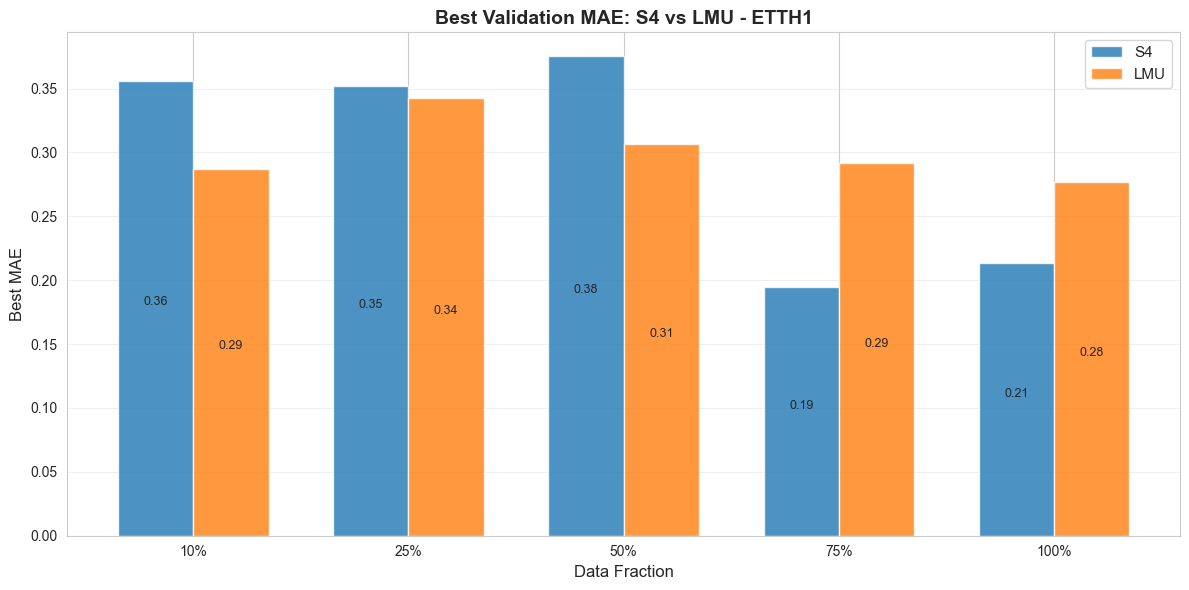

In [12]:
from src.eval.compare import plot_metric_comparison_bar

plot_metric_comparison_bar(
    all_results,
    metric_key='best_val_mae',
    title=f'Best Validation MAE: S4 vs LMU - {dataset.upper()}',
    ylabel='Best MAE',
)


## 8. Data Efficiency Analysis

Which model learns better with limited data?


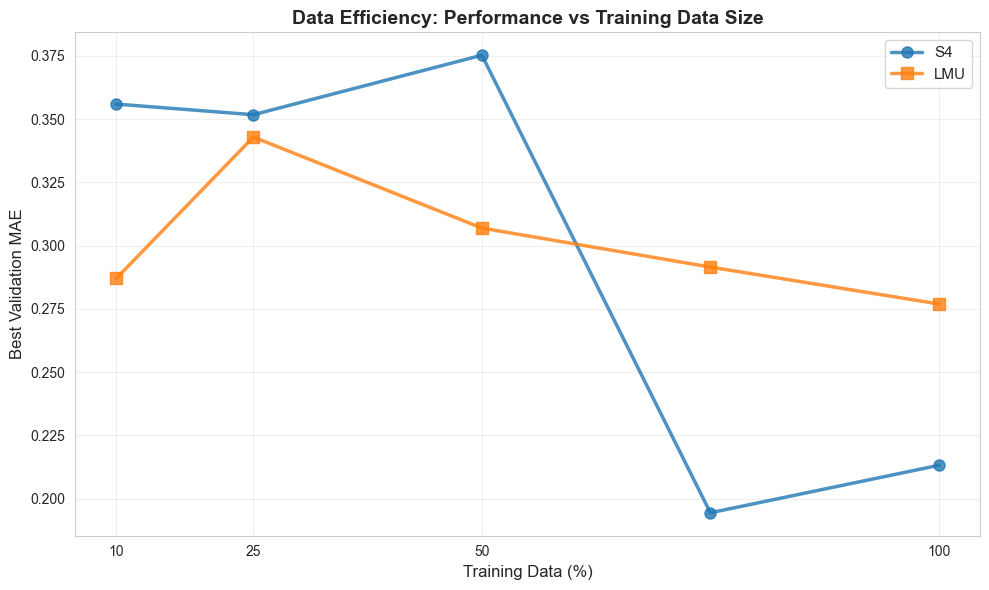

In [13]:
from src.eval.compare import plot_data_efficiency

plot_data_efficiency(
    all_results,
    metric_key='best_val_mae',
    ylabel='Best Validation MAE'
)


## 9. Winner Analysis

Which model performs best at each data fraction?


In [15]:
print("="*60)
print(f"WINNER ANALYSIS - {dataset.upper()}")
print("="*60)
print()

for frac in fractions:
    print(f"\n📊 Data Fraction: {int(frac*100)}%")
    print("-" * 40)

    best_model = None
    best_mae = float('inf')

    for model in models:
        results = all_results[model].get(frac, {})
        if results and 'best_val_mae' in results:
            mae = results['best_val_mae']
            print(f"  {model.upper():3s}: {mae:.4f}")

            if mae < best_mae:
                best_mae = mae
                best_model = model

    if best_model:
        print(f"\n Winner: {best_model.upper()} (MAE: {best_mae:.4f})")

        # Calculate margin
        for model in models:
            if model != best_model:
                other_results = all_results[model].get(frac, {})
                if other_results and 'best_val_mae' in other_results:
                    other_mae = other_results['best_val_mae']
                    improvement = ((other_mae - best_mae) / other_mae) * 100
                    print(f"  Beats {model.upper()} by {improvement:.1f}%")


WINNER ANALYSIS - ETTH1


📊 Data Fraction: 10%
----------------------------------------
  S4 : 0.3560
  LMU: 0.2870

 Winner: LMU (MAE: 0.2870)
  Beats S4 by 19.4%

📊 Data Fraction: 25%
----------------------------------------
  S4 : 0.3517
  LMU: 0.3429

 Winner: LMU (MAE: 0.3429)
  Beats S4 by 2.5%

📊 Data Fraction: 50%
----------------------------------------
  S4 : 0.3753
  LMU: 0.3069

 Winner: LMU (MAE: 0.3069)
  Beats S4 by 18.2%

📊 Data Fraction: 75%
----------------------------------------
  S4 : 0.1944
  LMU: 0.2915

 Winner: S4 (MAE: 0.1944)
  Beats LMU by 33.3%

📊 Data Fraction: 100%
----------------------------------------
  S4 : 0.2132
  LMU: 0.2769

 Winner: S4 (MAE: 0.2132)
  Beats LMU by 23.0%


## 11. Compare All Datasets (Optional)

Run this cell to compare performance across all ETT datasets at once.


In [16]:
import pandas as pd

datasets = ['etth1', 'etth2', 'ettm1', 'ettm2']
all_datasets_results = {}

print("="*60)
print("LOADING ALL DATASETS")
print("="*60)
print()

for ds in datasets:
    print(f"\nLoading {ds.upper()}...")
    all_datasets_results[ds] = load_etts_experiments(base_dir, models, fractions, ds)

print("\n" + "="*60)
print("SUMMARY ACROSS ALL DATASETS")
print("="*60)
print()

# Create comprehensive comparison
summary_rows = []

for ds in datasets:
    for model in models:
        for frac in fractions:
            results = all_datasets_results[ds][model].get(frac, {})
            if results and 'best_val_mae' in results:
                summary_rows.append({
                    'Dataset': ds.upper(),
                    'Model': model.upper(),
                    'Fraction': f"{int(frac*100)}%",
                    'Best MAE': f"{results['best_val_mae']:.4f}",
                    'Best Loss': f"{results.get('best_val_loss', 'N/A'):.4f}" if isinstance(results.get('best_val_loss'), (int, float)) else 'N/A',
                    'Epochs': results.get('epochs_trained', 'N/A')
                })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print()

# Save comprehensive results
csv_path = Path("./comparison_results_all_datasets.csv")
summary_df.to_csv(csv_path, index=False)
print(f"\nSaved to: {csv_path}")


LOADING ALL DATASETS


Loading ETTH1...
📂 Loading S4 @ 10%: etts_s4_task_etth1_frac10
📂 Loading S4 @ 25%: etts_s4_task_etth1_frac25
📂 Loading S4 @ 50%: etts_s4_task_etth1_frac50
📂 Loading S4 @ 75%: etts_s4_task_etth1_frac75
📂 Loading S4 @ 100%: etts_s4_task_etth1
📂 Loading LMU @ 10%: etts_lmu_task_etth1_frac10
📂 Loading LMU @ 25%: etts_lmu_task_etth1_frac25
📂 Loading LMU @ 50%: etts_lmu_task_etth1_frac50
📂 Loading LMU @ 75%: etts_lmu_task_etth1_frac75
📂 Loading LMU @ 100%: etts_lmu_task_etth1

Loading ETTH2...
📂 Loading S4 @ 10%: etts_s4_task_etth2_frac10
📂 Loading S4 @ 25%: etts_s4_task_etth2_frac25
📂 Loading S4 @ 50%: etts_s4_task_etth2_frac50
📂 Loading S4 @ 75%: etts_s4_task_etth2_frac75
📂 Loading S4 @ 100%: etts_s4_task_etth2
📂 Loading LMU @ 10%: etts_lmu_task_etth2_frac10
📂 Loading LMU @ 25%: etts_lmu_task_etth2_frac25
📂 Loading LMU @ 50%: etts_lmu_task_etth2_frac50
📂 Loading LMU @ 75%: etts_lmu_task_etth2_frac75
📂 Loading LMU @ 100%: etts_lmu_task_etth2

Loading ETTM1...
📂 Loadin

## 12. Cross-Dataset Visualization

Visualize model performance across all datasets with heatmaps.


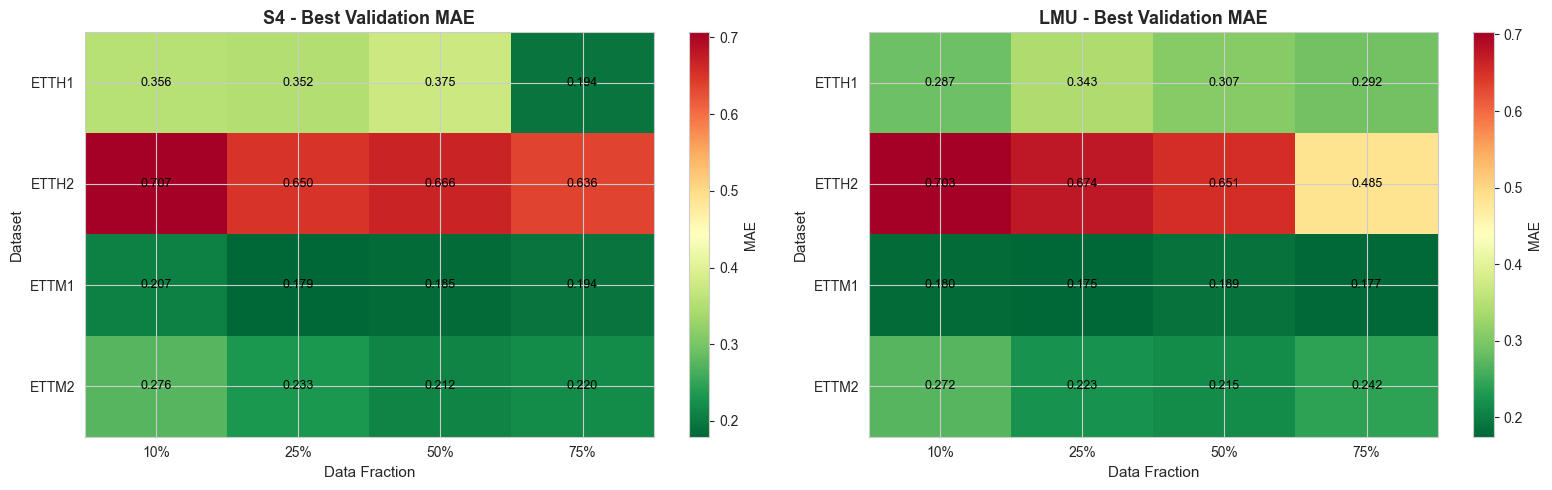

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for idx, model in enumerate(models):
    ax = axes[idx]

    # Prepare data matrix
    data = []
    for ds in datasets:
        row = []
        for frac in fractions:
            results = all_datasets_results[ds][model].get(frac, {})
            mae = results.get('best_val_mae', np.nan)
            row.append(mae)
        data.append(row)

    # Plot heatmap
    im = ax.imshow(data, aspect='auto', cmap='RdYlGn_r')

    # Set ticks and labels
    ax.set_xticks(range(len(fractions)))
    ax.set_xticklabels([f"{int(f*100)}%" for f in fractions])
    ax.set_yticks(range(len(datasets)))
    ax.set_yticklabels([ds.upper() for ds in datasets])

    # Add values to cells
    for i in range(len(datasets)):
        for j in range(len(fractions)):
            if not np.isnan(data[i][j]):
                text = ax.text(j, i, f'{data[i][j]:.3f}',
                             ha="center", va="center", color="black", fontsize=9)

    ax.set_xlabel('Data Fraction', fontsize=11)
    ax.set_ylabel('Dataset', fontsize=11)
    ax.set_title(f'{model.upper()} - Best Validation MAE', fontsize=13, fontweight='bold')

    # Colorbar
    plt.colorbar(im, ax=ax, label='MAE')

plt.tight_layout()
plt.show()


## 13. Key Findings

Based on the analysis above, document your key observations:

1. **Overall Performance**: Which model performs better on this dataset?
2. **Data Efficiency**: Which model maintains performance better with less data?
3. **Training Stability**: Which model shows more stable learning curves?
4. **Optimal Configuration**: What's the best model/fraction combination?

Add your observations in a markdown cell below or in your report.
